In [2]:
# 导入库
import numpy as np
import matplotlib.pyplot as plt
import os

In [4]:
# 加载数据集
data = np.loadtxt("data/dataset.txt")
print("数据集载入完成，共 {} 行".format(data.shape[0]))

数据集载入完成，共 800 行


In [5]:
# 分割训练集与测试集
train_data = data[:500, :]   # 前500行
test_data  = data[500:, :]   # 后300行

print("训练集大小：", train_data.shape)
print("测试集大小：", test_data.shape)

训练集大小： (500, 3)
测试集大小： (300, 3)


In [6]:
# 提取训练数据坐标和标签
x_train = train_data[:, 0]
y_train = train_data[:, 1]
labels_train = train_data[:, 2]

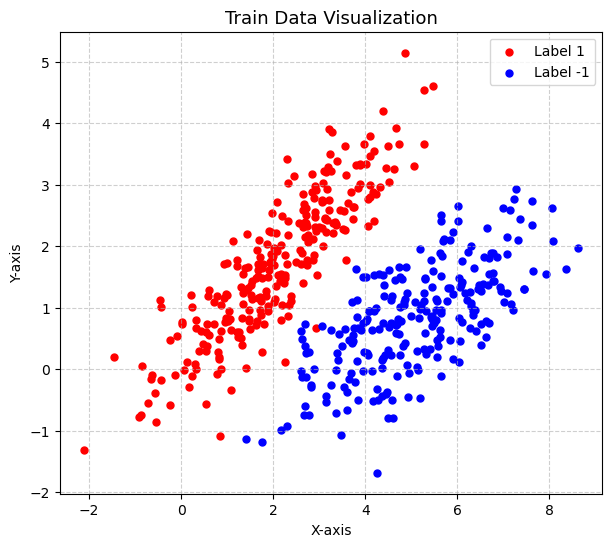

In [9]:
# 绘制训练数据分布图
# 创建画布
plt.figure(figsize=(7,6))
plt.title("Train Data Visualization", fontsize=13)

# 绘制红色与蓝色散点
plt.scatter(x_train[labels_train == 1],
            y_train[labels_train == 1],
            color='red', s=25, label='Label 1')

plt.scatter(x_train[labels_train == -1],
            y_train[labels_train == -1],
            color='blue', s=25, label='Label -1')

# 设置坐标轴标签
plt.xlabel("X-axis")
plt.ylabel("Y-axis")

# 显示图例、网格
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [10]:
# 提取训练集与测试集数据
x_train = train_data[:, 0:2]   # 前两列为坐标
y_train = train_data[:, 2]     # 第三列为类别标签

x_test = test_data[:, 0:2]
y_test = test_data[:, 2]

In [11]:
# 定义欧式距离函数
def euclidean_distance(x1, x2):
    """计算两个样本之间的欧式距离"""
    return np.sqrt(np.sum((x1 - x2) ** 2))

In [16]:
# 定义KNN分类器
def knn_predict(x_train, y_train, x_test, K):
    """
    对测试样本x_test进行KNN分类
    参数：
        x_train: 训练数据坐标 (N, 2)
        y_train: 训练标签 (N,)
        x_test : 测试数据坐标 (M, 2)
        K: 邻居数
    返回：
        y_pred: 预测标签 (M,)
    """
    y_pred = []
    for x in x_test:
        # 计算该测试样本与所有训练样本的距离
        distances = [euclidean_distance(x, x_t) for x_t in x_train]
        # 按距离排序，取最近K个
        nearest_indices = np.argsort(distances)[:K]
        nearest_labels = y_train[nearest_indices]
        # 多数表决法
        label = np.sign(np.sum(nearest_labels)
        y_pred.append(label)
    return np.array(y_pred)

In [17]:
# 测试不同K值下的分类结果
K_values = [1, 3, 5, 7, 9]

print("KNN分类结果：\n")
for K in K_values:
    y_pred = knn_predict(x_train, y_train, x_test, K)
    accuracy = np.mean(y_pred == y_test)
    print(f"K = {K} ：准确率 = {accuracy*100:.2f}%")

KNN分类结果：

K = 1 ：准确率 = 99.00%
K = 3 ：准确率 = 99.00%
K = 5 ：准确率 = 99.33%
K = 7 ：准确率 = 99.33%
K = 9 ：准确率 = 99.00%


In [18]:
# 输出示例（显示前10个预测结果）
print("\n测试集前10个样本预测结果对比：")
for i in range(10):
    print(f"样本 {i+1}: 真实标签={int(y_test[i])}, 预测标签={int(y_pred[i])}")


测试集前10个样本预测结果对比：
样本 1: 真实标签=-1, 预测标签=-1
样本 2: 真实标签=-1, 预测标签=-1
样本 3: 真实标签=-1, 预测标签=-1
样本 4: 真实标签=-1, 预测标签=-1
样本 5: 真实标签=-1, 预测标签=-1
样本 6: 真实标签=-1, 预测标签=1
样本 7: 真实标签=1, 预测标签=1
样本 8: 真实标签=1, 预测标签=1
样本 9: 真实标签=-1, 预测标签=-1
样本 10: 真实标签=-1, 预测标签=-1


In [21]:
# 提取训练集数据
X = train_data[:, 0:2]   # 坐标
y = train_data[:, 2]     # 标签（1 或 -1）

# 定义欧式距离函数
def euclidean_distance(a, b):
    """计算两个样本之间的欧式距离"""
    return np.sqrt(np.sum((a - b) ** 2))

In [22]:
# 定义KNN分类器
def knn_predict(X_train, y_train, X_test, K):
    """KNN分类预测"""
    y_pred = []
    for x in X_test:
        # 计算与所有训练样本的距离
        distances = [euclidean_distance(x, x_t) for x_t in X_train]
        # 找到最近K个样本
        nearest_idx = np.argsort(distances)[:K]
        nearest_labels = y_train[nearest_idx]
        # 多数表决
        label = np.sign(np.sum(nearest_labels))
        y_pred.append(label)
    return np.array(y_pred)

In [23]:
# 实现5折交叉验证
K_values = [1, 3, 5, 7, 9]
fold_num = 5
fold_size = len(X) // fold_num

# 存储平均准确率
avg_accuracies = {K: [] for K in K_values}

print("===== 5-Fold 交叉验证结果 =====\n")

for fold in range(fold_num):
    # 定义当前折的验证集范围
    start = fold * fold_size
    end = (fold + 1) * fold_size
    
    # 划分验证集与训练集
    X_val = X[start:end]
    y_val = y[start:end]
    X_train = np.concatenate((X[:start], X[end:]), axis=0)
    y_train = np.concatenate((y[:start], y[end:]), axis=0)
    
    print(f"Fold {fold+1}:")
    
    # 对不同K进行测试
    for K in K_values:
        y_pred = knn_predict(X_train, y_train, X_val, K)
        acc = np.mean(y_pred == y_val)
        avg_accuracies[K].append(acc)
        print(f"  K = {K} -> 准确率: {acc*100:.2f}%")
    
    print("-" * 40)

===== 5-Fold 交叉验证结果 =====

Fold 1:
  K = 1 -> 准确率: 99.00%
  K = 3 -> 准确率: 99.00%
  K = 5 -> 准确率: 99.00%
  K = 7 -> 准确率: 99.00%
  K = 9 -> 准确率: 99.00%
----------------------------------------
Fold 2:
  K = 1 -> 准确率: 98.00%
  K = 3 -> 准确率: 99.00%
  K = 5 -> 准确率: 99.00%
  K = 7 -> 准确率: 99.00%
  K = 9 -> 准确率: 98.00%
----------------------------------------
Fold 3:
  K = 1 -> 准确率: 100.00%
  K = 3 -> 准确率: 100.00%
  K = 5 -> 准确率: 100.00%
  K = 7 -> 准确率: 100.00%
  K = 9 -> 准确率: 100.00%
----------------------------------------
Fold 4:
  K = 1 -> 准确率: 99.00%
  K = 3 -> 准确率: 99.00%
  K = 5 -> 准确率: 99.00%
  K = 7 -> 准确率: 99.00%
  K = 9 -> 准确率: 99.00%
----------------------------------------
Fold 5:
  K = 1 -> 准确率: 99.00%
  K = 3 -> 准确率: 98.00%
  K = 5 -> 准确率: 100.00%
  K = 7 -> 准确率: 98.00%
  K = 9 -> 准确率: 99.00%
----------------------------------------


In [1]:
# 计算每个K的平均准确率
print("===== 各K值平均准确率 =====")
for K in K_values:
    mean_acc = np.mean(avg_accuracies[K])
    print(f"K = {K}: 平均准确率 = {mean_acc*100:.2f}%")

# 找出最佳K值
best_K = max(K_values, key=lambda k: np.mean(avg_accuracies[k]))
best_acc = np.mean(avg_accuracies[best_K])
print("\n\n\n最佳K值为:", best_K)
print(f"平均准确率最高为: {best_acc*100:.2f}%")

===== 各K值平均准确率 =====


NameError: name 'K_values' is not defined